# Hand tracking demo - MediaPipe (local runtime)

This demo reads a LeRobot dataset, runs hand tracking (MediaPipe) as a Daft UDF with `track_hands`, and shows the keypoints. Every method returns the same schema: a list of `{handedness, confidence, kp2d, kp3d?}` per frame (`kp3d` is null for MediaPipe).

## Setup

Install with `pip install "daft-physical-ai[mediapipe]" matplotlib`, then import.

In [1]:
import os
import sys

# Daft's progress bar leaks fds under Jupyter and can crash the kernel
# (Eventual-Inc/daft-physical-ai#24); disable it there until fixed upstream.
if "ipykernel" in sys.modules:
    os.environ["DAFT_PROGRESS_BAR"] = "0"

from daft.datasets import lerobot

from daft_physical_ai.hands import track_hands

## Configure

The dataset, the camera column to decode, and how many frames to run.

In [2]:
DATASET = "pepijn223/egodex-test"
IMAGE_COLUMN = "observation.image"
LIMIT = 12

## Read the dataset

The LeRobot reader gives one row per frame, decoding the camera into an image column.

In [3]:
df = lerobot.read(DATASET, load_video_frames=IMAGE_COLUMN).limit(LIMIT)

## Track hands

`track_hands` returns a hand-pose column. It's a lazy, batched Daft UDF, so nothing runs until we materialize below.

In [4]:
df = df.with_column("hands", track_hands(df[IMAGE_COLUMN], method="mediapipe"))

## Inspect the results

`.show()` triggers execution and renders the keypoints per frame.

In [5]:
df.select("episode_index", "frame_index", "hands").show()

episode_indexInt64,frame_indexInt64,"handsList[Struct[handedness: String, confidence: Float32, kp2d: List[List[Float32]], kp3d: List[List[Float32]]]]"
0,0,"[{handedness: right,confidence: 0.9790868,kp2d: [[1409.5848, 1109.521], [1357.4954, 1075.738], [1311.899, 1034.6724], [1261.1387, 1008.1239], [1222.2706, 984.70123], [1362.7334, 955.6213], [1303.7606, 904.7308], [1258.9319, 904.3764], [1230.4058, 913.8319], [1371.7897, 967.7707], [1309.5277, 915.9226], [1264.9574, 912.1919], [1229.4375, 921.5512], [1370.1735, 985.5805], [1316.7963, 946.244], [1277.4364, 940.39746], [1244.3204, 947.4744], [1368.0823, 1003.53516], [1321.43, 977.695], [1288.7034, 972.52246], [1258.5966, 974.56323]],kp3d: None,}, {handedness: right,confidence: 0.7482122,kp2d: [[954.672, 1074.0482], [950.0958, 1010.5392], [976.9469, 960.2988], [1006.152, 934.15546], [1029.2639, 916.3094], [1001.08704, 931.82007], [1031.5956, 904.28467], [1049.5156, 902.2173], [1065.8038, 905.4154], [1008.8876, 951.80963], [1027.2899, 928.1998], [1022.01666, 933.272], [1019.79443, 941.099], [1015.234, 966.3137], [1027.7479, 941.0143], [1016.63684, 946.03156], [1009.60236, 953.79395], [1024.663, 977.1456], [1022.3339, 956.63306], [1015.6724, 958.78357], [1010.2112, 961.97906]],kp3d: None,}]"
0,1,"[{handedness: right,confidence: 0.98324096,kp2d: [[1406.2035, 1108.8458], [1352.6927, 1072.6556], [1307.6647, 1032.1688], [1259.4242, 1006.5043], [1222.366, 983.9279], [1363.8561, 954.93823], [1307.085, 903.10065], [1261.8833, 900.21], [1233.2085, 907.6238], [1373.5992, 968.313], [1313.9866, 914.0828], [1267.7191, 907.97174], [1231.333, 916.6064], [1371.6853, 987.1745], [1319.9066, 945.53326], [1278.6158, 937.0847], [1245.0743, 942.6058], [1368.4417, 1006.37366], [1321.0447, 980.2684], [1286.8796, 973.6655], [1256.4536, 974.7627]],kp3d: None,}, {handedness: right,confidence: 0.76023126,kp2d: [[954.5771, 1071.5254], [955.35504, 1009.6562], [982.3467, 961.31036], [1009.89636, 934.89624], [1030.0793, 916.4238], [1000.78674, 932.3615], [1030.7777, 903.27716], [1049.2188, 900.68823], [1065.1989, 904.0892], [1007.19324, 951.5051], [1027.5486, 926.5981], [1025.3971, 929.72394], [1025.4305, 935.62366], [1013.15314, 966.25146], [1027.5643, 939.84344], [1020.44574, 942.79767], [1015.98413, 948.8405], [1022.02295, 977.6907], [1021.7696, 957.02435], [1017.35333, 958.6012], [1013.73346, 961.746]],kp3d: None,}]"
0,2,"[{handedness: right,confidence: 0.97795737,kp2d: [[1410.8853, 1107.5798], [1357.5541, 1074.1953], [1312.255, 1033.5516], [1262.4691, 1006.4989], [1221.9084, 984.76965], [1363.0939, 957.2459], [1307.7952, 902.1808], [1265.0264, 895.2634], [1236.5381, 898.9636], [1372.1536, 967.4411], [1314.3649, 914.5002], [1271.9584, 904.41284], [1236.1034, 907.5958], [1371.0302, 984.6553], [1322.1934, 944.69385], [1284.1523, 931.0383], [1249.5453, 928.62756], [1368.3596, 1002.7205], [1322.7216, 978.6496], [1290.098, 972.3417], [1259.0667, 972.2323]],kp3d: None,}, {handedness: right,confidence: 0.82196695,kp2d: [[953.91736, 1076.048], [961.0326, 1020.3857], [988.023, 972.14294], [1012.29443, 945.8959], [1028.1271, 923.8639], [991.085, 932.28345], [1030.0328, 902.7268], [1053.1752, 900.98553], [1071.7233, 904.89984], [995.99176, 948.64404], [1028.2008, 924.6613], [1027.2296, 932.9568], [1026.1139, 941.4134], [1002.709, 961.83044], [1025.678, 936.1534], [1020.6466, 945.55316], [1017.3829, 953.63], [1011.7867, 971.3603], [1019.6331, 951.861], [1017.96606, 958.28687], [1013.8733, 963.743]],kp3d: None,}]"
0,3,"[{handedness: right,confidence: 0.9760107,kp2d: [[1411.5732, 1105.092], [1357.3431, 1071.2482], [1311.932, 1032.7607], [1262.433, 1008.1202], [1222.6572, 987.4398], [1362.5823, 955.62476], [1309.1655, 901.93945], [1268.1558, 893.46106], [1240.3828, 896.51117], [1372.3177, 966.6562], [1318.7239, 910.87524], [1278.3691, 900.83575], [1244.2618, 903.56177], [1372.0593, 983.4935], [1327.9235, 940.87335], [1292.1703, 926.6258], [1259.7683, 924.6168], [1370.2374, 1000.4036], [1331.2487, 972.33264], [1301.6047, 9

## Evaluate against ground truth

EgoDex ships per-frame GT hand poses, so we can score the predictions: project both GT hands, match the predicted hands to them, and report detect% + PCK. The matching runs as a Daft UDF (`score`); the summary is computed from the collected results.

> EgoDex-specific (GT layout + camera intrinsics). Needs `pip install scipy`.

In [6]:
# --- Evaluation against EgoDex ground truth (2D, wrist + 5 fingertips) ---
# EgoDex-specific: GT hand poses live in observation.state (left = dims 0-23,
# right = 24-47); the camera is observation.extrinsics. Needs scipy + numpy.
import numpy as np
from scipy.optimize import linear_sum_assignment

import daft
from daft import DataType, col

FX = FY = 736.6339          # EgoDex camera intrinsics
CX, CY = 960.0, 540.0
SIX = [0, 4, 8, 12, 16, 20]  # wrist + 5 fingertip keypoints
THRESH = [0.1, 0.2, 0.3]     # PCK thresholds (normalized)


def _hand_pts(state, side):
    b = side * 24            # 24 dims per hand: wrist(3) + joints; we take wrist + 5 tips
    return np.vstack([state[b : b + 3], state[b + 9 : b + 24].reshape(5, 3)])


def _project(points_world, extr):
    cam_from_world = np.linalg.inv(np.asarray(extr, float).reshape(4, 4))
    cam = (cam_from_world @ np.hstack([points_world, np.ones((len(points_world), 1))]).T).T[:, :3]
    z = cam[:, 2]
    with np.errstate(divide="ignore", invalid="ignore"):
        uv = np.stack([FX * cam[:, 0] / z + CX, FY * cam[:, 1] / z + CY], axis=1)
    uv[z <= 0] = np.nan
    return uv


def _norm(p):               # translation + scale invariant (hand size)
    p = p - p[0]
    return p / (np.linalg.norm(p[1:], axis=1).mean() + 1e-9)


def _pair_err(gt6, pred6):  # per-keypoint error, fingertips matched by assignment
    g, m = _norm(gt6), _norm(pred6)
    d = np.linalg.norm(g[1:, None] - m[None, 1:], axis=2)
    r, c = linear_sum_assignment(d)
    return np.concatenate([[0.0], d[r, c]])


_ERR = DataType.struct({
    "n_gt": DataType.int64(),
    "n_matched": DataType.int64(),
    "errs": DataType.list(DataType.list(DataType.float64())),
})


@daft.func(return_dtype=_ERR)
def score(hands, state, extr):
    """Match predicted hands to the 2 GT hands (Hungarian on normalized error)."""
    gts = [uv for uv in (_project(_hand_pts(np.asarray(state, float), s), extr) for s in (0, 1)) if np.isfinite(uv).all()]
    preds = [np.asarray(h["kp2d"], float)[SIX] for h in (hands or [])]
    if not gts or not preds:
        return {"n_gt": len(gts), "n_matched": 0, "errs": []}
    pair = [[_pair_err(g, p) for p in preds] for g in gts]
    cost = np.array([[e.mean() for e in row] for row in pair])
    r, c = linear_sum_assignment(cost)   # match predicted hands to GT hands
    return {"n_gt": len(gts), "n_matched": len(r), "errs": [[float(x) for x in pair[i][j]] for i, j in zip(r, c)]}


def report(label, scores):
    n_gt = sum(s["n_gt"] for s in scores)
    matched = sum(s["n_matched"] for s in scores)
    errs = [e for s in scores for hand in s["errs"] for e in hand]
    mean_errs = [float(np.mean(hand)) for s in scores for hand in s["errs"]]
    pck = [100 * np.mean([e < t for e in errs]) if errs else 0.0 for t in THRESH]
    detect = 100 * matched / n_gt if n_gt else 0.0
    mean = float(np.mean(mean_errs)) if mean_errs else float("nan")
    print(f"{label:12} detect={detect:3.0f}%  mean_err={mean:.3f}  "
          f"PCK@.1/.2/.3 = {pck[0]:.0f}/{pck[1]:.0f}/{pck[2]:.0f}")

In [7]:
df = df.with_column("score_hands", score(col("hands"), col("observation.state"), col("observation.extrinsics")))
scored = df.select("score_hands").to_pydict()

In [8]:
print("EgoDex 2D accuracy:")
report("MediaPipe", scored["score_hands"])

EgoDex 2D accuracy:
MediaPipe    detect=100%  mean_err=0.116  PCK@.1/.2/.3 = 49/84/96


## Visualize: ground truth vs predictions

Each row is a frame; the first column is the EgoDex ground-truth hands (green), the rest are the predicted keypoints. This is the most telling view - you see where each method is right and where it misses.

In [9]:
# --- Visualize: draw the predicted keypoints on a few frames ---
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 21-keypoint hand skeleton (wrist + 5 fingers x 4 joints)
BONES = [(0, 1), (1, 2), (2, 3), (3, 4), (0, 5), (5, 6), (6, 7), (7, 8),
         (0, 9), (9, 10), (10, 11), (11, 12), (0, 13), (13, 14), (14, 15),
         (15, 16), (0, 17), (17, 18), (18, 19), (19, 20)]


def draw_hands(img, hands):
    img = np.ascontiguousarray(img)
    for h in hands or []:
        kp = np.asarray(h["kp2d"], float)
        for a, b in BONES:
            cv2.line(img, tuple(kp[a].astype(int)), tuple(kp[b].astype(int)), (60, 200, 60), 2)
        for p in kp:
            cv2.circle(img, tuple(p.astype(int)), 3, (255, 80, 0), -1)
    return img

def draw_gt(img, state, extr):
    """Draw the projected EgoDex GT hands (wrist + fingertips) in green."""
    img = np.ascontiguousarray(img)
    for side in (0, 1):
        uv = _project(_hand_pts(np.asarray(state, float), side), extr)
        if not np.isfinite(uv).all():
            continue
        wrist = tuple(uv[0].astype(int))
        for tip in uv[1:]:
            cv2.line(img, wrist, tuple(tip.astype(int)), (0, 220, 0), 2)
            cv2.circle(img, tuple(tip.astype(int)), 5, (255, 0, 0), -1)
        cv2.circle(img, wrist, 6, (0, 120, 255), -1)
    return img

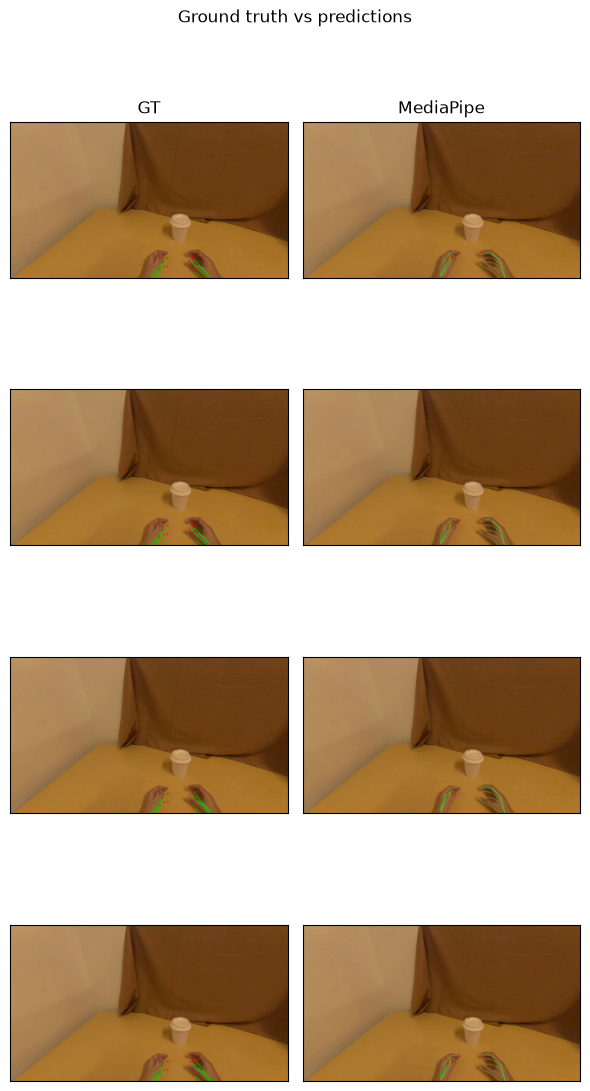

In [10]:
viz = df.select(IMAGE_COLUMN, "observation.state", "observation.extrinsics", "hands").limit(4).to_pydict()
columns = [("GT", None)] + [("MediaPipe", "hands")]
n = len(viz["frame_index"]) if "frame_index" in viz else len(viz[IMAGE_COLUMN])
fig, axes = plt.subplots(n, len(columns), figsize=(3 * len(columns), 3 * n), squeeze=False)
for i in range(n):
    img = np.asarray(viz[IMAGE_COLUMN][i])
    for jc, (label, c) in enumerate(columns):
        cell = (draw_gt(img.copy(), viz["observation.state"][i], viz["observation.extrinsics"][i])
                if c is None else draw_hands(img.copy(), viz[c][i]))
        axes[i][jc].imshow(cell)
        axes[i][jc].set_xticks([])
        axes[i][jc].set_yticks([])
        if i == 0:
            axes[i][jc].set_title(label)
fig.suptitle("Ground truth vs predictions")
plt.tight_layout()
plt.show()